### The Gradient of a Function

The gradient of a function at a point is a vector that points in the direction of the steepest ascent of the function at that point. The magnitude (or length) of the gradient vector is equal to the rate of increase of the function in that direction.
Contour lines (or level sets) of a function are curves that connect points where the function has the same value. For a 2D function, these are like the lines of constant altitude on a topographic map.
There are a few key relationships between gradients and contour lines:
1. The gradient at a point is perpendicular (or orthogonal) to the contour line passing through that point. This is because the contour line represents the direction of no change in the function value, while the gradient represents the direction of maximum change.
2. The gradient points in the direction where the function increases most rapidly. If you were to walk along the contour line (where the function value doesn't change), the direction you'd need to go to start climbing as steeply as possible is the direction of the gradient.
3. The magnitude of the gradient (how long the gradient vector is) indicates how steeply the function is increasing. If the contour lines are close together, that means the function is changing rapidly, so the gradient is large. If the contour lines are far apart, the function is changing slowly, so the gradient is small.

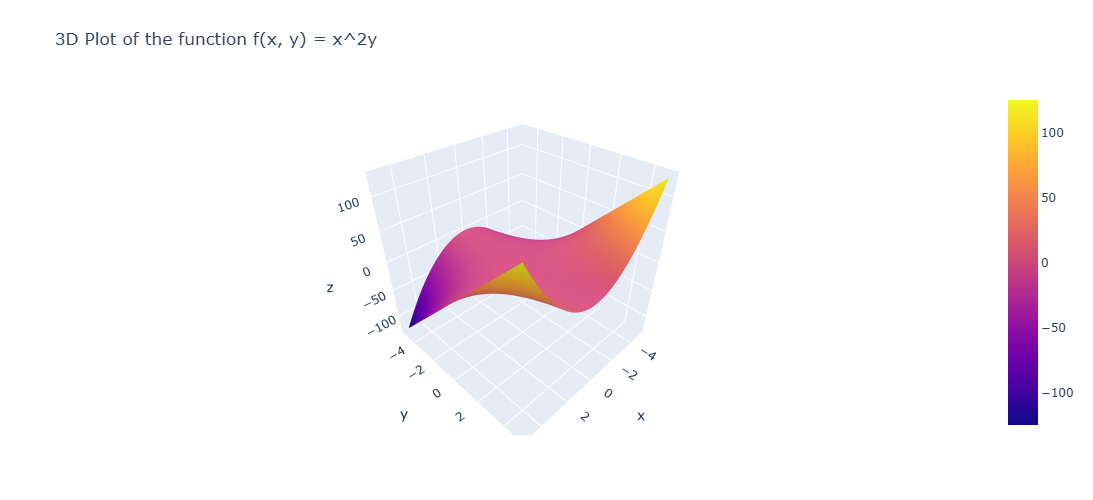

In [1]:
import plotly.graph_objects as go
import numpy as np
x = np.linspace (-5, 5, 100)
y = np.linspace (-5, 5, 100)
x, y = np.meshgrid(x, y)
z = x**2 * y
fig = go. Figure(data=[go. Surface (z=z, x=x, y=y)])
fig.update_layout(title='3D Plot of the function f(x, y) = x^2y', autosize=False,
width=500, height=500,
margin=dict(l=65, r=50, b=65, t=90))
fig.show()

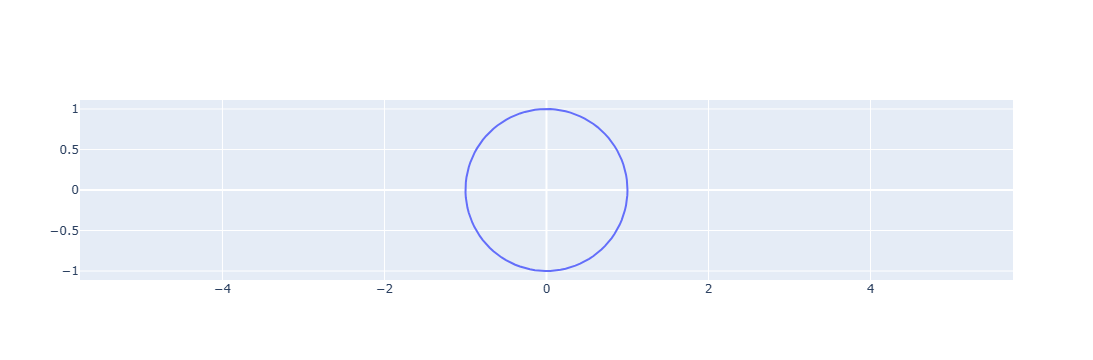

In [2]:
import plotly.graph_objects as go
import numpy as np
#Create a set of points that lie on the circle
theta =  np.linspace(0, 2*np.pi, 100)
x= np.cos(theta)
y= np.sin(theta)
# Create the plot
fig =  go.Figure(data=go.Scatter(x=x, y=y, mode='lines'))
# Set the aspect ratio to equal so the circle doesn't look like an ellipse
fig.update_yaxes(
scaleanchor = "x",
scaleratio = 1,
)
fig.show()


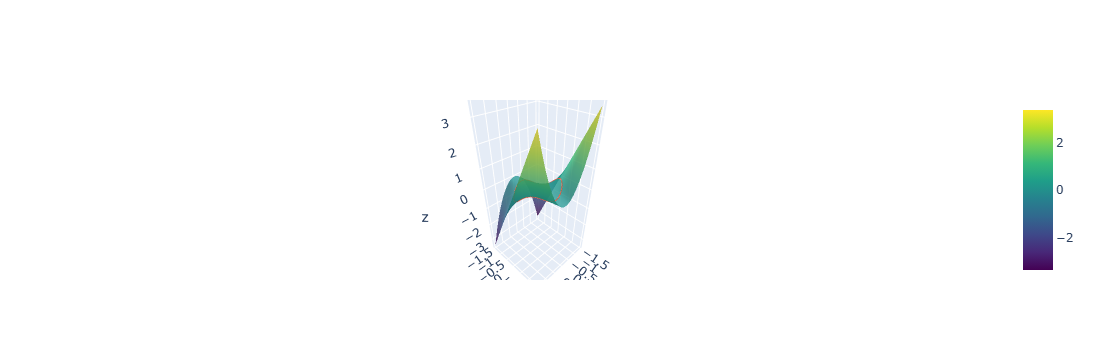

In [3]:
import plotly.graph_objects as go
import numpy as np
#Create grid for the function
x = np.linspace(-1.5, 1.5, 100)
y = np.linspace(-1.5, 1.5, 100)
x, y =  np.meshgrid(x, y)
z= x**2 * y
# Create a set of points that lie on the circle
theta = np.linspace(0, 2*np.pi, 100)
x_circle =  np.cos(theta)
y_circle = np.sin(theta)
z_circle  = x_circle**2* y_circle
#Create the surface plot for the function
fig = go.Figure(data=[go.Surface (z=z, x=x, y=y, colorscale='Viridis', opacity=0.8)])
#Add the circle to the plot
fig.add_trace(go.Scatter3d(x=x_circle, y=y_circle, z=z_circle, mode='lines'))
fig.show()

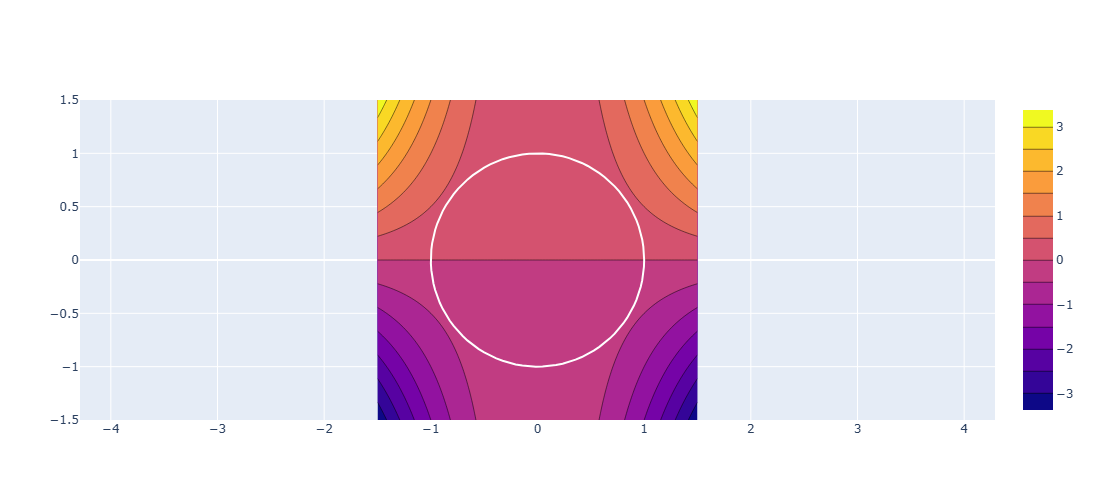

In [4]:
import plotly.graph_objects as go
import numpy as np
# Create grid for the function
x = np.linspace (-1.5, 1.5, 100)
y = np.linspace(-1.5, 1.5, 100)
x, y = np.meshgrid(x, y)
z = x**2*y
# Create a set of points that lie on the circle
theta = np.linspace(0, 2*np.pi, 100)
x_circle = np.cos(theta)
y_circle = np.sin(theta)
# Create the contour plot for the function
fig = go.Figure(data=go.Contour (x=x[0,:], y=y[:,0], z=z))
# Add the circle to the plot
fig.add_trace(go.Scatter(x=x_circle, y=y_circle, mode='lines', line=dict(color='white')))

#Set aspect ratio
fig.update_layout(
                autosize=False,
                width=500,
                height=500,
                yaxis=dict(scaleanchor="x", scaleratio=1),
                )
fig.show()

## gradient (direction of maximum change) at each point on the graph

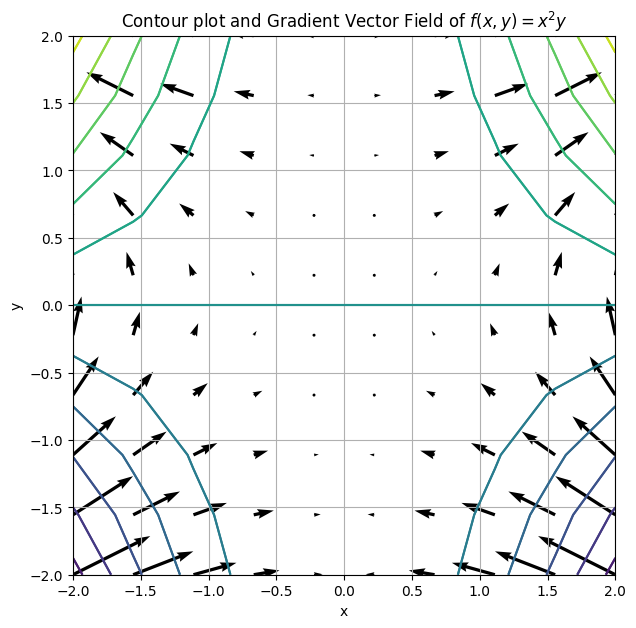

In [5]:
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(-2, 2, 10)
y = np.linspace(-2, 2, 10)
X, Y = np.meshgrid(x, y)
# Compute the function values
Z = (X**2) * Y
# Compute the gradient
U = 2*X*Y
V = X**2
plt.figure(figsize=(7, 7))
# Draw the contour plot
plt.contour (X, Y, Z, levels=10, cmap='viridis')

#Draw the contour plot
plt.contour (X, Y, Z, levels=10, cmap='viridis')
#Draw the gradient vector field
plt.quiver(X, Y, U, V)
plt.title('Contour plot and Gradient Vector Field of $f(x, y) = x^2y$')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

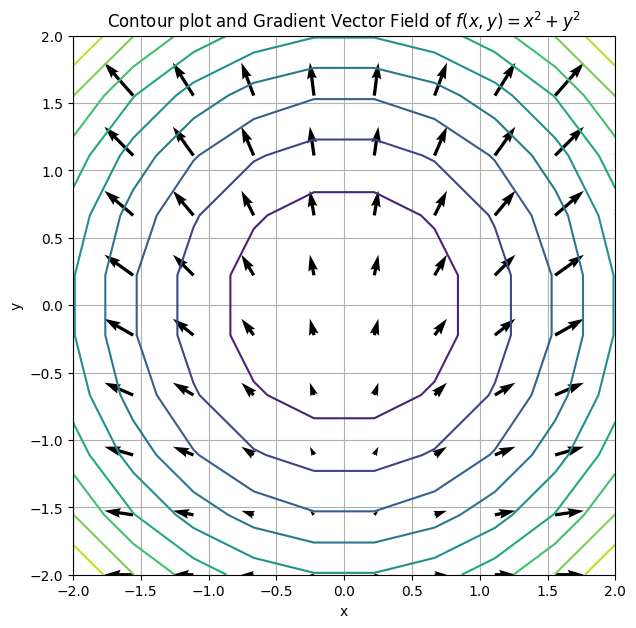

In [6]:
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(-2, 2, 10)
y = np.linspace(-2, 2, 10)
X, Y = np.meshgrid(x, y)
# Compute the function values
Z = X**2 + Y**2
# Compute the gradient
U = 2*X
V = 2+Y
plt.figure(figsize=(7, 7))
# Draw the contour plot
plt.contour (X, Y, Z, levels=10, cmap='viridis')
#Draw the gradient vector field
plt.quiver(X, Y, U, V)

plt.title('Contour plot and Gradient Vector Field of $f(x, y) = x^2 + y^2$')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

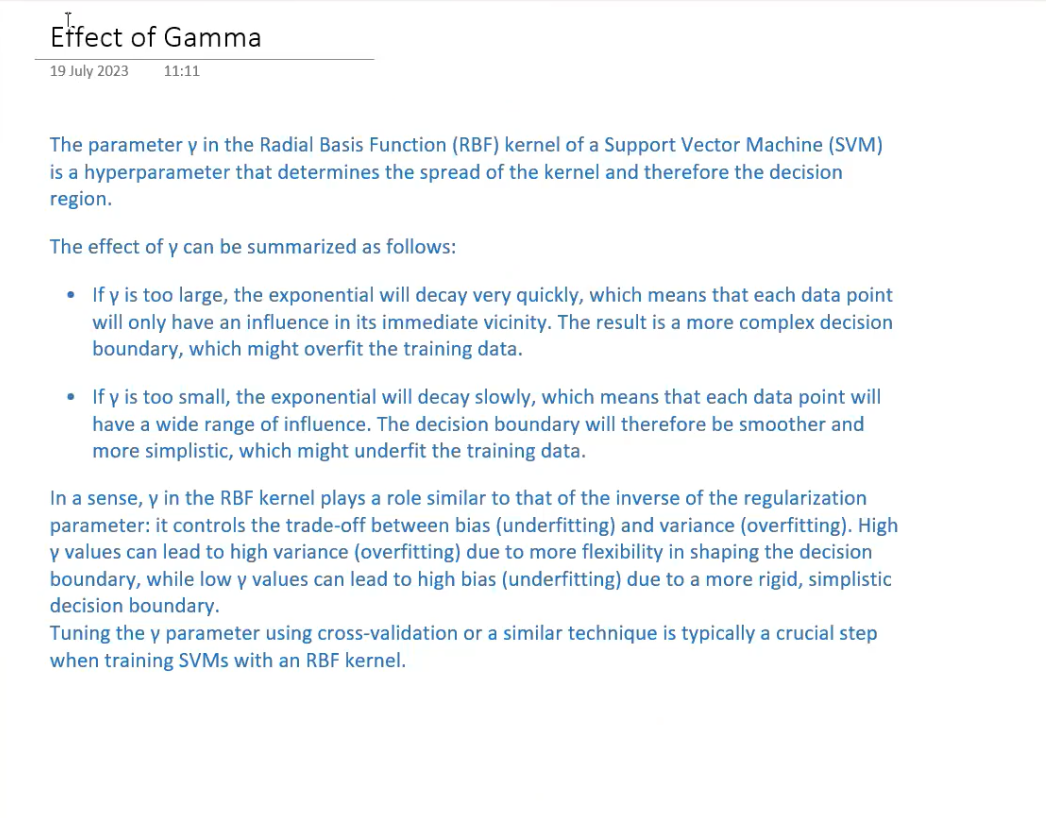

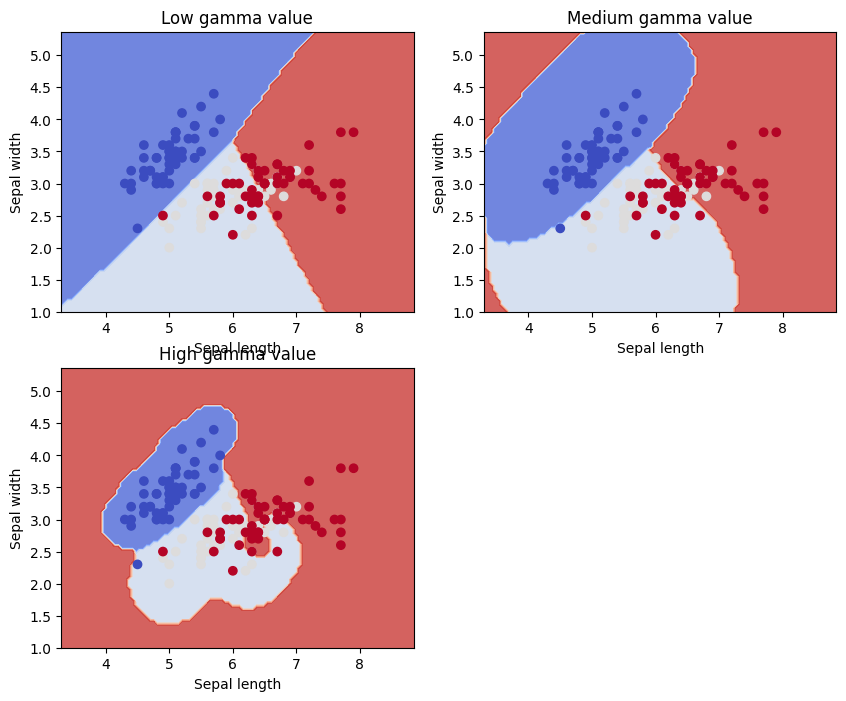

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn import svm
from sklearn.model_selection import train_test_split

# Load iris dataset
iris = datasets.load_iris()

X = iris.data[:, :2]   # first two features
y = iris.target

# Create mesh grid
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1

h = (x_max - x_min)/100

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)

# Titles
titles = ['Low gamma value', 'Medium gamma value', 'High gamma value']

# Gamma values
gamma_values = [0.1, 1, 10]

# Regularization parameter
C = 1.0

plt.figure(figsize=(10,8))

for i, gamma in enumerate(gamma_values):

    clf = svm.SVC(kernel='rbf', gamma=gamma, C=C)
    clf.fit(X_train, y_train)

    plt.subplot(2,2,i+1)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

    plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.coolwarm)

    plt.xlabel("Sepal length")
    plt.ylabel("Sepal width")
    plt.title(titles[i])

plt.show()

### Custom Kernels
1. String kernels: These are used for classifying text or sequences, where the input data is not numerical. String kernels measure the similarity between two strings. For example, a simple string kernel might count the number of common substrings between two strings.
2. Chi-square kernel: This kernel is often used in computer vision problems, especially for histogram comparison. It's defined as K(x,y) = exp(-yx²(x, y)), where x²(x, y) is the chi-square distance between the histograms & and y.
3. Intersection kernel: This is another kernel commonly used in computer vision, which
computes the intersection between two histograms (or generally non-negative feature vectors).
4. Hellinger's kernel: Hellinger's kernel, or Bhattacharyya kernel, is used for comparing probability distributions and is popular in image recognition tasks.
5. Radial basis function network (RBFN) kernels: These are similar to the standard RBF
kernel, but the centers and widths of the RBFs are learned from the data, rather than being fixed a priori.
6. Spectral kernels: These kernels use spectral analysis techniques to compare data points. They can be particularly useful for dealing with cyclic or periodic data.